# Task 2A — Use case definition and dataset engineering
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nazifmhd/Task-1---Financial-AI/blob/main/task2_genai/01_generate_dataset.ipynb)

## Problem statement
**Use case: financial compliance clause extraction.** Compliance and legal teams at banks,
insurers and fintechs review hundreds of contract and policy clauses (loan agreements, outsourcing
contracts, KYC policies, data-processing agreements) to log *who must do what, when, and how risky
it is*. General-purpose small LLMs return prose, invent obligations, or use labels outside the
firm's taxonomy. We fine-tune a 3.8B model to produce faithful, schema-conformant extractions.

| | Definition |
|---|---|
| **Input** | one clause (15–220 words) from a financial-sector contract or policy |
| **Output** | JSON with exactly: `clause_type` (10-label taxonomy), `obligation` (≤ 40-word faithful paraphrase of the primary duty), `party_responsible` (copied verbatim from the clause), `trigger_condition` (activating event, or `null`), `risk_flag` (`low`/`medium`/`high` per a written rubric) |
| **Correct** | valid JSON with the five keys and allowed enum values; `clause_type` matches the reference; the obligation, party and trigger are all supported by the clause text |
| **Partially correct** | valid JSON, nothing invented, but a wrong `clause_type`/`risk_flag`, a secondary obligation instead of the primary one, or a missed trigger |
| **Incorrect / hallucinated** | not parseable JSON, or states an obligation, party, amount, deadline or condition that does not appear in the clause |

**Taxonomy (10):** indemnification, termination, payment_terms, confidentiality, liability_cap,
force_majeure, compliance_covenant, data_protection, aml_kyc, regulatory_reporting.

**Teacher ≠ student:** data is generated by **`openai/gpt-oss-120b`** (Groq free tier; the blueprint's
Llama-3.3-70B has been retired from Groq), and the fine-tuned student is **`microsoft/Phi-3-mini-4k-instruct`**,
a different model family. The teacher is ~30x larger than the student.

In [1]:
# Windows: torch must be imported before scikit-learn, otherwise their OpenMP
# runtimes clash (WinError 1114 loading c10.dll). Harmless elsewhere.
try:
    import torch
except ImportError:
    pass
import os, sys, json, warnings, logging
if os.path.basename(os.getcwd()) != "task2_genai" and os.path.isdir("task2_genai"):
    os.chdir("task2_genai")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)
for n in ("httpx", "openai", "urllib3", "sentence_transformers", "chromadb", "huggingface_hub"):
    logging.getLogger(n).setLevel(logging.WARNING)
import pandas as pd
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from IPython.display import display, Markdown, Image
import config
print("cwd:", os.getcwd())

cwd: E:\CDAZZDEV\Task-1---Financial-AI\task2_genai


## 1. Generation design
Diversity is designed in before any call is made. A **stratified plan** fixes each example's
clause type (24 per type) and cycles balanced, shuffled values for industry (8), document type (10),
jurisdiction (8) and complexity (5). 20% of specs ask for an unconditional clause (null trigger).
The teacher writes 3 examples per call, each from a different spec, at temperature 0.9.

In [2]:
from src import gen
plan = gen.build_plan()
plan_df = pd.DataFrame(plan)
print(f"{len(plan)} planned examples")
display(plan_df.head(6))
print("\nExample user prompt sent to the teacher:\n")
print(gen.batch_user_prompt(plan[:3]))

240 planned examples


,clause_type,industry,document_type,jurisdiction,complexity,has_trigger,spec_id
0,compliance_covenant,digital asset custody,syndicated loan agreement,Hong Kong,a single plain sentence,True,0
1,indemnification,insurance,investment management agreement,Ireland (EU),a single plain sentence,True,1
2,data_protection,fintech payments,cloud outsourcing contract,England and Wales,two to three sentences with a defined deadline or amount,True,2
3,compliance_covenant,asset management,insurance policy wording,New York,two to three sentences with a defined deadline or amount,True,3
4,indemnification,asset management,correspondent banking agreement,Singapore,a dense clause with cross-references and nested conditions,False,4
5,payment_terms,microfinance and leasing,syndicated loan agreement,Sri Lanka,a dense clause with cross-references and nested conditions,True,5



Example user prompt sent to the teacher:

Generate 3 examples, in this order:
1. clause_type=compliance_covenant; a clause from a syndicated loan agreement in digital asset custody, governed by the law of Hong Kong; written as a single plain sentence; include an explicit trigger condition.
2. clause_type=indemnification; a clause from a investment management agreement in insurance, governed by the law of Ireland (EU); written as a single plain sentence; include an explicit trigger condition.
3. clause_type=data_protection; a clause from a cloud outsourcing contract in fintech payments, governed by the law of England and Wales; written as two to three sentences with a defined deadline or amount; include an explicit trigger condition.
Return {"examples": [...]} with exactly 3 items.


### Full teacher system prompt (`prompts/teacher_system_prompt.txt`)
Required by the brief. It is printed verbatim below and stored in the repository.

In [3]:
print(gen.TEACHER_SYSTEM_PROMPT)

You are a senior financial-services compliance lawyer and data annotator. You write
realistic contract and policy clauses from the financial sector and annotate each one with
a faithful structured extraction. Your output is used as gold-standard training data, so
accuracy and faithfulness matter more than anything else.

## Annotation schema (exact keys, exact order)
{
  "clause_type": one label from the taxonomy below,
  "obligation": the single primary duty the clause imposes, as a concise paraphrase
                (max 40 words) that uses only facts stated in the clause,
  "party_responsible": the party that must perform the obligation, copied EXACTLY as
                       it is named in the clause text (e.g. "the Borrower", "Acme Pay Ltd"),
  "trigger_condition": the event or condition that activates the obligation, as a short
                       paraphrase from the text; null if the obligation is unconditional
                       or no trigger is stated,
  "risk_flag": 

## 2. Run (resumable) generation
`generate()` skips specs that are already in `data/raw_generated.jsonl`. The full run was done
once with this code; the log of that run is shown, and re-running the cell confirms nothing is left to generate.

In [4]:
print(open("outputs/generation_log.txt", encoding="utf-8").read()[-1500:])
stats = gen.generate()          # resumes; 0 calls if the dataset is complete
print("\nThis execution:", stats)

2026-10-07 17:13:46,253 INFO calls=10 written=30 failed=0 tokens=15392
2026-10-07 17:15:45,324 INFO calls=20 written=60 failed=0 tokens=30499
2026-10-07 17:17:47,077 INFO calls=30 written=90 failed=0 tokens=45313
2026-10-07 17:19:45,264 INFO calls=40 written=120 failed=0 tokens=59794
2026-10-07 17:21:44,853 INFO calls=50 written=150 failed=0 tokens=74671
2026-10-07 17:23:48,678 INFO calls=60 written=180 failed=0 tokens=90218
2026-10-07 17:25:14,773 WARNING validation failed (attempt 1): Extra data: line 1 column 1037 (char 1036)
2026-10-07 17:25:53,655 INFO calls=70 written=210 failed=0 tokens=107583
{'planned': 240, 'already_done': 3, 'calls': 79, 'failed_calls': 0, 'written': 237, 'tokens': 121373}




This execution: {'planned': 240, 'already_done': 240, 'calls': 0, 'failed_calls': 0, 'written': 0, 'tokens': 0}


## 3. Quality control
The teacher is strong but not perfect, so every row is checked before use:
* the label matches the requested `clause_type`;
* `party_responsible` appears verbatim in the clause (a faithfulness guard);
* clause length is 15–220 words and the obligation is ≤ 45 words;
* no trigger when the spec asked for an unconditional clause;
* the label name is not leaked into the clause text;
* near-duplicates (TF-IDF cosine > 0.85) are removed.

In [5]:
qc = gen.run_qc()
print(json.dumps(qc, indent=1))
rej = pd.read_json(config.REJECTED_PATH, lines=True) if config.REJECTED_PATH.stat().st_size else pd.DataFrame()
if len(rej):
    display(rej.assign(clause=rej.input_text.str[:110])[["qc_reasons", "clause"]].head(10))

{
 "raw": 240,
 "kept": 240,
 "rejected": 0,
 "reject_reasons": {}
}


## 4. Sample examples

In [6]:
clean = pd.read_json(config.CLEAN_PATH, lines=True)
for _, r in clean.sample(3, random_state=1).iterrows():
    print("CLAUSE:", r.input_text); print("TARGET:", json.dumps(r.output, ensure_ascii=False)); print("-" * 100)

CLAUSE: The Service Provider shall, within ten (10) Business Days after receipt of a written request from the Asset Manager pursuant to Clause 12.4(a) and in compliance with the DIFC Financial Services Authority's (FSA) reporting obligations under Rule 5.3 of the DIFC Markets Rulebook, prepare and submit to the FSA a consolidated report detailing all cloud‑hosting incidents, data‑location changes and third‑party sub‑processor engagements relating to the Services, provided that such incidents have been classified as “material” under Schedule 3.1; if the Asset Manager fails to deliver the requisite request within the stipulated period, the reporting obligation shall be deemed waived for that reporting cycle.
TARGET: {"clause_type": "regulatory_reporting", "obligation": "prepare and submit a consolidated report to the DIFC FSA detailing material cloud‑hosting incidents and related information", "party_responsible": "The Service Provider", "trigger_condition": "receipt of a written request

## 5. Diversity validation
Evidence that the set is not "minor variations of one scenario":
length distribution, label balance, coverage of every generation axis, keyword/topic frequency,
lexical (TF-IDF) and semantic (MiniLM embedding) pairwise similarity, and distinct-n.

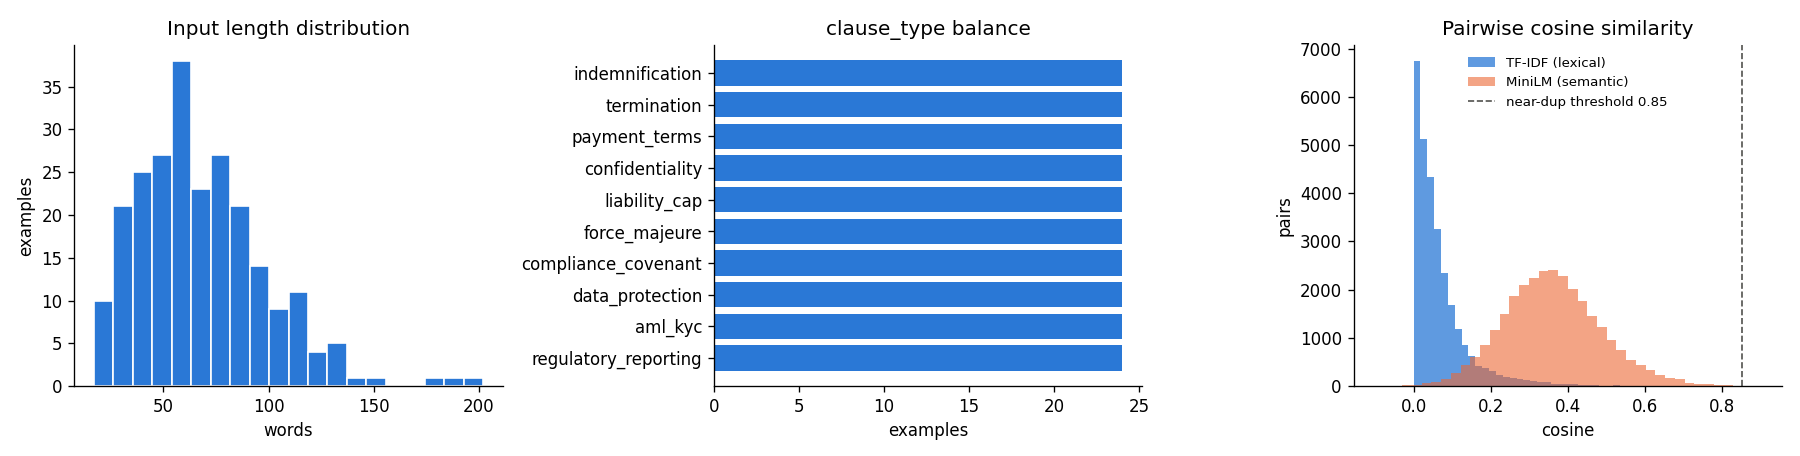

{
 "n_examples": 240,
 "length_words": {
  "min": 17,
  "median": 63.0,
  "mean": 68.42916666666666,
  "max": 202,
  "std": 30.605064656668983
 },
 "unique_parties": 56,
 "distinct_1": 0.0829873057302171,
 "distinct_2": 0.36382236129498136,
 "lexical_tfidf_cosine": {
  "mean": 0.06679521620230967,
  "p95": 0.21409216875215856,
  "max": 0.7121971528603293
 },
 "semantic_minilm_cosine": {
  "mean": 0.36146557331085205,
  "p95": 0.5807801067829133,
  "max": 0.9043212532997131
 },
 "lexical_pairs_above": {
  ">0.5": 30,
  ">0.7": 1,
  ">0.8": 0,
  ">0.9": 0,
  "total_pairs": 28680
 },
 "semantic_pairs_above": {
  ">0.5": 3805,
  ">0.7": 234,
  ">0.8": 42,
  ">0.9": 1,
  "total_pairs": 28680
 },
 "trigger_null_share": 0.24583333333333332,
 "risk_flag": {
  "medium": 122,
  "high": 70,
  "low": 48
 }
}


In [7]:
from src import diversity
rows = diversity.load_rows()
rep = diversity.report(rows, plot_path=config.OUTPUT_DIR / "diversity.png")
display(Image(filename=str(config.OUTPUT_DIR / "diversity.png")))
print(json.dumps({k: rep[k] for k in ["n_examples", "length_words", "unique_parties", "distinct_1",
                                      "distinct_2", "lexical_tfidf_cosine", "semantic_minilm_cosine",
                                      "lexical_pairs_above", "semantic_pairs_above",
                                      "trigger_null_share", "risk_flag"]}, indent=1))

In [8]:
cov = rep["axes_coverage"]
display(pd.DataFrame({"axis": list(cov), "distinct values": [len(v) for v in cov.values()],
                      "min count": [min(v.values()) for v in cov.values()],
                      "max count": [max(v.values()) for v in cov.values()]}))
display(pd.DataFrame(rep["clause_type"], index=["examples"]).T.sort_index())

,axis,distinct values,min count,max count
0,industry,8,30,30
1,document_type,10,24,24
2,jurisdiction,8,30,30
3,complexity,5,48,48


,examples
aml_kyc,24
compliance_covenant,24
confidentiality,24
data_protection,24
force_majeure,24
indemnification,24
liability_cap,24
payment_terms,24
regulatory_reporting,24
termination,24


In [9]:
print("Topic check - top TF-IDF terms per clause type:")
display(diversity.top_terms_per_class(rows))
print("Most frequent bigrams (stop-words removed) and the share of examples containing them:")
display(diversity.bigram_frequency([r["input_text"] for r in rows], k=15))

Topic check - top TF-IDF terms per clause type:


,top TF-IDF terms
indemnification,"breach, indemnify, shall indemnify, harmless, hold harmless, hold"
termination,"notice, termination, party, terminate, written notice, written"
payment_terms,"invoice, fee, business, pay, shall, shall pay"
confidentiality,"information, confidential, confidential information, party, shall, disclose"
liability_cap,"liability, 000, loss, aggregate, aggregate liability, arising"
force_majeure,"event, force majeure, majeure, force, performance, party"
compliance_covenant,"compliance, shall, regulatory, applicable, regulations, bank"
data_protection,"data, personal, personal data, measures, data protection, protection"
aml_kyc,"diligence, customer, customer diligence, verification, shall, money laundering"
regulatory_reporting,"report, authority, regulatory, submit, shall, bank"


Most frequent bigrams (stop-words removed) and the share of examples containing them:


,bigram,count,share_of_examples_%
0,business days,91,34.6
1,service provider,54,13.8
2,provider shall,43,14.2
3,force majeure,42,10.4
4,personal data,42,12.5
5,thirty 30,37,15.4
6,10 business,36,15.0
7,30 days,33,13.8
8,written notice,32,12.9
9,days receipt,32,13.3


**Reading the numbers (240 examples, 28,680 pairs).**
* **Lexical redundancy is low.** Mean TF-IDF cosine is 0.067. Only 30 pairs (0.1%) exceed 0.5, one exceeds 0.7, and none reaches the 0.85 near-duplicate threshold.
* **Semantic similarity is higher, as expected inside one domain.** The mean is 0.36. 42 pairs (0.15%) exceed 0.8 and a single pair exceeds 0.9: two clauses of the same type that share a topic but have different parties, amounts and wording. No cluster of near-copies exists.
* **Every generation axis is fully covered and balanced:** 10 clause types × 24, 8 industries × 30, 10 document types × 24, 8 jurisdictions × 30, 5 complexity levels × 48. Lengths range from 17 to 202 words.
* **Top terms per class are class-specific** (e.g. *hold harmless*, *aggregate liability*, *customer due diligence*), so the labels are learnable from content. The most common bigram, *business days*, appears in about a third of the clauses. That is ordinary contract vocabulary, not a template.

## 6. Chat-template JSONL and stratified 80/10/10 split

In [10]:
from src import format_split
sizes = format_split.build()
print("Split sizes:", sizes, "| total:", sum(sizes.values()))
print({k: f"{v / sum(sizes.values()):.0%}" for k, v in sizes.items()})
for s in ("val", "test"):
    print(s, "classes covered:", len({r["clause_type"] for r in format_split.load_split(s)}), "/ 10")
ex = format_split.load_split("train")[0]
print("\nOne train.jsonl line (messages with system / user / assistant roles):")
print(json.dumps(ex, indent=1, ensure_ascii=False)[:1500])

Split sizes: {'train': 192, 'val': 24, 'test': 24} | total: 240
{'train': '80%', 'val': '10%', 'test': '10%'}


val classes covered: 10 / 10
test classes covered: 10 / 10

One train.jsonl line (messages with system / user / assistant roles):
{
 "id": "ex069",
 "clause_type": "indemnification",
 "messages": [
  {
   "role": "system",
   "content": "You are a financial compliance extraction model. Read the clause and return ONLY a JSON object with exactly these keys in this order:\n{\"clause_type\": one of [indemnification, termination, payment_terms, confidentiality, liability_cap, force_majeure, compliance_covenant, data_protection, aml_kyc, regulatory_reporting],\n \"obligation\": the primary duty the clause imposes, a concise paraphrase (max 40 words) using only facts in the clause,\n \"party_responsible\": the party that must perform it, copied exactly as named in the clause,\n \"trigger_condition\": the event that activates the obligation, or null if unconditional,\n \"risk_flag\": one of [low, medium, high]}\nNever invent obligations, parties, amounts or deadlines that are not in the clause

In [11]:
# The same example rendered with the student's own chat template (what the model actually sees):
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(config.BASE_MODEL)
print(tok.apply_chat_template(ex["messages"], tokenize=False))

<|system|>
You are a financial compliance extraction model. Read the clause and return ONLY a JSON object with exactly these keys in this order:
{"clause_type": one of [indemnification, termination, payment_terms, confidentiality, liability_cap, force_majeure, compliance_covenant, data_protection, aml_kyc, regulatory_reporting],
 "obligation": the primary duty the clause imposes, a concise paraphrase (max 40 words) using only facts in the clause,
 "party_responsible": the party that must perform it, copied exactly as named in the clause,
 "trigger_condition": the event that activates the obligation, or null if unconditional,
 "risk_flag": one of [low, medium, high]}
Never invent obligations, parties, amounts or deadlines that are not in the clause.<|end|>
<|user|>
The Bank shall indemnify and hold harmless the Processor against any loss, claim, cost or expense arising out of any breach of data protection obligations by the Bank, and the Processor shall be entitled to recover such amoun

In [12]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
                   capture_output=True, text=True)
print(r.stdout[-800:])

........                                                                 [100%]
8 passed in 2.11s

